## fine tuninng

In [20]:
import torch

print(f"Is CUDA actually awake?: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We are running on: {device}")

Is CUDA actually awake?: True
We are running on: cuda


In [21]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer

print("May the GPU gods have mercy on your soul...")

# 1. Load the RAW Tabular Data because we actually need the text to train the text model
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")

#using complete training data now, as compared to the previously 90k samples from training data

# Create the text inputs and use the LOG-TRANSFORMED salaries as the labels
train_texts = (df_train['Title'].fillna("") + " | " + df_train['FullDescription'].fillna("")).tolist()
train_labels = np.log1p(df_train['SalaryNormalized'].values).astype(np.float32)

valid_texts = (df_valid['Title'].fillna("") + " | " + df_valid['FullDescription'].fillna("")).tolist()
valid_labels = np.log1p(df_valid['SalaryNormalized'].values).astype(np.float32)

# 2. Setup Tokenizer and Model
# num_labels=1 tells BERT we are doing Regression (predicting a single continuous number)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# Load the model and immediately lock it to the GPU
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=1).to(device)
# 3. Convert to Hugging Face Dataset format
def create_hf_dataset(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'label': labels # Trainer automatically looks for a column named 'label'
    })

print("Tokenizing the text...")
train_dataset = create_hf_dataset(train_texts, train_labels)
valid_dataset = create_hf_dataset(valid_texts, valid_labels)


May the GPU gods have mercy on your soul...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2146.34it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing the text...


In [22]:

# 4. The God-Tier Training Arguments for 6GB VRAM
training_args = TrainingArguments(
    output_dir='../data/results',
    eval_strategy="epoch",
    learning_rate=2e-5,               # Keep it low so it doesn't forget English
    per_device_train_batch_size=8,    # TINY batch size so your VRAM doesn't explode
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,    # Fakes a batch size of 32 (8 * 4)
    num_train_epochs=2,               # 2 is enough. Any more and it overfits.
    weight_decay=0.01,
    fp16=True,                        # MIXED PRECISION: Saves 50% VRAM. Crucial for RTX 4050.
    save_strategy="epoch",
    logging_steps=100
)

# 5. Build a custom metric to track MAE during training
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Reverse the log so the MAE makes sense in real money
    preds_real = np.expm1(predictions).flatten()
    labels_real = np.expm1(labels)
    mae = np.mean(np.abs(preds_real - labels_real))
    return {"mae": mae}

# 6. Train the Beast
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

print("Starting training. Touch grass while you wait.")
trainer.train()

# 7. Save the Fine-Tuned Model
trainer.save_model("../data/my_finetuned_distilbert")
tokenizer.save_pretrained("../data/my_finetuned_distilbert")
print("Model saved! You survived.")

Starting training. Touch grass while you wait.


Epoch,Training Loss,Validation Loss,Mae
1,0.549926,0.069432,7739.010254
2,0.488239,0.062609,6866.547852


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.59it/s]

Model saved! You survived.


## Embeddings generation

In [23]:
import torch
from transformers import DistilBertTokenizer, DistilBertModel

# 1. Check if your GPU is actually awake
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} (If this says CPU, we have a problem)")

# 2. Download/Load the Tokenizer and the Model
# 'distilbert-base-uncased' means it makes all text lowercase (easier for it to read)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# 3. Move the model to your RTX 4050
model = model.to(device)

# 4. We are NOT training, so tell PyTorch to freeze the weights
model.eval() 

print("DistilBERT is locked and loaded on the GPU.")

Using device: cuda (If this says CPU, we have a problem)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1090.00it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT is locked and loaded on the GPU.


In [24]:
import numpy as np
from tqdm import tqdm
import torch
import pandas as pd

df = pd.read_csv(r"../data/train.csv")
# 1. Grab the text (Replace 'df' with whatever your dataframe is named)
# FILLNA IS CRUCIAL because if BERT sees a NaN (blank space), it will crash instantly.
# Let's just do the first 100 rows to test it so you don't cry. Change this later!
texts = df['FullDescription'].fillna("").head(100).tolist() 

batch_size = 16 # Keep this low (16 or 32). Your 6GB VRAM is weak.
all_embeddings = []

print("Starting the extraction... pray to the GPU gods.")

# 2. The Loop
for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i+batch_size]
    
    # Tokenize: Cuts sentences into pieces. 
    # max_length=128 ensures we don't read huge essays and crash the VRAM.
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    
    # Move the chopped up text to your GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Run it through the model WITHOUT gradients (saves massive memory)
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Grab the [CLS] token (the first token of every sentence). 
    # This single token contains the "summary/vibe" of the whole job description.
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    
    # Move it back to the CPU and convert to numbers so we can save it
    all_embeddings.append(cls_embeddings.cpu().numpy())

# 3. Stack all the batches together into one giant table of numbers
final_features = np.vstack(all_embeddings)

print(f"Done! We got an embedding matrix of shape: {final_features.shape}")

Starting the extraction... pray to the GPU gods.


100%|██████████| 7/7 [00:01<00:00,  4.44it/s]

Done! We got an embedding matrix of shape: (100, 768)


In [25]:
import pandas as pd
df_train = pd.read_csv(r"../data/train.csv")
df_valid = pd.read_csv(r"../data/valid.csv")
df_test = pd.read_csv(r"../data/test.csv")

In [26]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from transformers import DistilBertTokenizer, DistilBertModel

# 1. Point this to YOUR fine-tuned folder!
model_path = '../data/my_finetuned_distilbert'

print("Waking up the Finance Bro BERT...")
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
# We use DistilBertModel (not Classification) because we only want the embeddings!
model = DistilBertModel.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval() # Freeze it!

# 2. Load the RAW data (because we need the text, as you smartly pointed out)
print("Loading raw data...")
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")
df_test = pd.read_csv("../data/test.csv")

# Glue them
for df in [df_train, df_valid, df_test]:
    df['Combined_Text'] = df['Title'].fillna("Unknown") + " | " + df['FullDescription'].fillna("Unknown")

# 3. The Extraction Function
def extract_money_vibes(text_series, batch_size=32):
    texts = text_series.tolist()
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_vibe = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_vibe)
        
    return np.vstack(all_embeddings)

# 4. Extract and Overwrite
print("Nuking Train Data with new vibes...")
np.save("../data/train_embeds.npy", extract_money_vibes(df_train['Combined_Text']))

print("Nuking Valid Data with new vibes...")
np.save("../data/valid_embeds.npy", extract_money_vibes(df_valid['Combined_Text']))

print("Nuking Test Data with new vibes...")
np.save("../data/test_embeds.npy", extract_money_vibes(df_test['Combined_Text']))

print("Extraction complete. Absolute cinema.")

Waking up the Finance Bro BERT...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2812.36it/s]
DistilBertModel LOAD REPORT from: ../data/my_finetuned_distilbert
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading raw data...
Nuking Train Data with new vibes...


100%|██████████| 7649/7649 [41:16<00:00,  3.09it/s]  


Nuking Valid Data with new vibes...


100%|██████████| 1914/1914 [11:27<00:00,  2.79it/s]


Nuking Test Data with new vibes...


100%|██████████| 1914/1914 [11:01<00:00,  2.89it/s]


Extraction complete. Absolute cinema.


## encoding

In [27]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

print("Starting the ultimate pipeline... grab a chai.")

# 0. Output folder setup
os.makedirs("../data/model_ready/", exist_ok=True)

# 1. LOAD THE TABULAR DATA
df_train = pd.read_csv("../data/train.csv")
df_valid = pd.read_csv("../data/valid.csv")
df_test = pd.read_csv("../data/test.csv")

global_mean = df_train['SalaryNormalized'].mean()

# ==========================================
# 2. THE GOD-TIER HIERARCHICAL LOCATION ENCODER
# ==========================================
print("Parsing the Location Tree like a boss...")

# A. Read the tree into a dictionary: leaf -> full path
# e.g. 'Shadwell': ['UK', 'London', 'East London', 'Shadwell']
tree_paths = {}
with open('../data/Location_tree.csv', 'r', encoding='utf-8') as f:
    for line in f:
        # Clean up the line and split by ~
        path = line.strip().replace('"', '').split('~')
        leaf = path[-1]
        tree_paths[leaf] = path 

# B. Hierarchical Location Encoding with OOF to prevent leakage
print("Calculating geographical wealth with OOF...")

def get_loc_means(df):
    node_sals = defaultdict(list)
    for loc, salary in zip(df['LocationNormalized'], df['SalaryNormalized']):
        if loc in tree_paths:
            for region in tree_paths[loc]:
                node_sals[region].append(salary)
        else:
            node_sals[loc].append(salary)
    return {node: np.mean(sals) for node, sals in node_sals.items()}

def enc_loc(loc, m_dict, g_mean):
    if loc in tree_paths:
        for region in reversed(tree_paths[loc]):
            if region in m_dict:
                return m_dict[region]
    if loc in m_dict:
        return m_dict[loc]
    return g_mean

from sklearn.model_selection import KFold
kf_te = KFold(n_splits=5, shuffle=True, random_state=42)

oof_loc = np.zeros(len(df_train))
for tr_idx, va_idx in kf_te.split(df_train):
    tr_fold = df_train.iloc[tr_idx]
    va_fold = df_train.iloc[va_idx]
    fold_means = get_loc_means(tr_fold)
    oof_loc[va_idx] = va_fold['LocationNormalized'].apply(lambda x: enc_loc(x, fold_means, global_mean))

full_loc_means = get_loc_means(df_train)
df_valid['LocationNormalized'] = df_valid['LocationNormalized'].apply(lambda x: enc_loc(x, full_loc_means, global_mean))
df_test['LocationNormalized'] = df_test['LocationNormalized'].apply(lambda x: enc_loc(x, full_loc_means, global_mean))
df_train['LocationNormalized'] = oof_loc

# ==========================================
# 3. OOF TARGET ENCODING (To prevent leakage!)
# ==========================================
print("Target encoding Company, Category, and SourceName using OOF to prevent leakage...")
from sklearn.model_selection import KFold
kf_te = KFold(n_splits=5, shuffle=True, random_state=42)
target_cols = ['Company', 'Category', 'SourceName']

for col in target_cols:
    oof_encoded = np.zeros(len(df_train))
    for tr_idx, va_idx in kf_te.split(df_train):
        tr_fold = df_train.iloc[tr_idx]
        va_fold = df_train.iloc[va_idx]
        col_means = tr_fold.groupby(col)['SalaryNormalized'].mean()
        oof_encoded[va_idx] = va_fold[col].map(col_means).fillna(global_mean)
        
    full_col_means = df_train.groupby(col)['SalaryNormalized'].mean()
    df_valid[col] = df_valid[col].map(full_col_means).fillna(global_mean)
    df_test[col] = df_test[col].map(full_col_means).fillna(global_mean)
    df_train[col] = oof_encoded

# ==========================================
# 4. TF-IDF + SVD TEXT FEATURES (NEW for 32GB RAM)
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("Extracting TF-IDF features (Warning: Uses ~10GB RAM)...")
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english')

# Combine Title and FullDescription
train_text = df_train['Title'].fillna("") + " | " + df_train['FullDescription'].fillna("")
valid_text = df_valid['Title'].fillna("") + " | " + df_valid['FullDescription'].fillna("")
test_text = df_test['Title'].fillna("") + " | " + df_test['FullDescription'].fillna("")

# Fit only on train to prevent data leakage
train_tfidf = tfidf.fit_transform(train_text)
valid_tfidf = tfidf.transform(valid_text)
test_tfidf = tfidf.transform(test_text)

print("Reducing 20,000 dimensions to 150 dense components with SVD...")
svd = TruncatedSVD(n_components=150, random_state=42)
train_svd = svd.fit_transform(train_tfidf)
valid_svd = svd.transform(valid_tfidf)
test_svd = svd.transform(test_tfidf)

svd_cols = [f"tfidf_svd_{i}" for i in range(150)]
df_train_svd = pd.DataFrame(train_svd, index=df_train.index, columns=svd_cols)
df_valid_svd = pd.DataFrame(valid_svd, index=df_valid.index, columns=svd_cols)
df_test_svd = pd.DataFrame(test_svd, index=df_test.index, columns=svd_cols)

print("Stitching SVD features...")
df_train = pd.concat([df_train, df_train_svd], axis=1)
df_valid = pd.concat([df_valid, df_valid_svd], axis=1)
df_test = pd.concat([df_test, df_test_svd], axis=1)

# ==========================================
# 4b. DROP THE TRASH
# ==========================================
drop_cols = ['Id', 'Title', 'FullDescription', 'LocationRaw']
print("Taking out the garbage...")
for df in [df_train, df_valid, df_test]:
    df.drop(columns=drop_cols, errors='ignore', inplace=True)

# ==========================================
# 5. ONE-HOT ENCODING
# ==========================================
ohe_cols = ['ContractType', 'ContractTime']
print("One-Hot Encoding...")
df_train = pd.get_dummies(df_train, columns=ohe_cols, dummy_na=True)
df_valid = pd.get_dummies(df_valid, columns=ohe_cols, dummy_na=True)
df_test = pd.get_dummies(df_test, columns=ohe_cols, dummy_na=True)

df_train, df_valid = df_train.align(df_valid, join='left', axis=1, fill_value=0)
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

# ==========================================
# 6. LOAD THE DISTILBERT EMBEDDINGS
# ==========================================
print("Loading the DistilBERT brain juice...")
train_emb = np.load("../data/train_embeds.npy")
valid_emb = np.load("../data/valid_embeds.npy")
test_emb = np.load("../data/test_embeds.npy")

emb_cols = [f"bert_{i}" for i in range(train_emb.shape[1])]
df_train_emb = pd.DataFrame(train_emb, index=df_train.index, columns=emb_cols)
df_valid_emb = pd.DataFrame(valid_emb, index=df_valid.index, columns=emb_cols)
df_test_emb = pd.DataFrame(test_emb, index=df_test.index, columns=emb_cols)

# ==========================================
# 7. THE GRAND STITCHING
# ==========================================
print("Stitching it all together...")
final_train = pd.concat([df_train, df_train_emb], axis=1)
final_valid = pd.concat([df_valid, df_valid_emb], axis=1)
final_test = pd.concat([df_test, df_test_emb], axis=1)

# ==========================================
# 8. SAVE AS PARQUET
# ==========================================
print("Saving to ../data/model_ready/ as Parquet...")
final_train.to_parquet("../data/model_ready/train_final.parquet", index=False)
final_valid.to_parquet("../data/model_ready/valid_final.parquet", index=False)
final_test.to_parquet("../data/model_ready/test_final.parquet", index=False)

print(f"Done! Final Train Shape: {final_train.shape}")
print("Your hierarchy logic is flawless. Go run this and nuke the competition.")

Starting the ultimate pipeline... grab a chai.
Parsing the Location Tree like a boss...
Calculating geographical wealth with OOF...
Target encoding Company, Category, and SourceName using OOF to prevent leakage...
Extracting TF-IDF features (Warning: Uses ~10GB RAM)...
Reducing 20,000 dimensions to 150 dense components with SVD...
Stitching SVD features...
Taking out the garbage...
One-Hot Encoding...
Loading the DistilBERT brain juice...
Stitching it all together...
Saving to ../data/model_ready/ as Parquet...
Done! Final Train Shape: (244768, 929)
Your hierarchy logic is flawless. Go run this and nuke the competition.


## Ensemble model

In [28]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import pandas as pd 
import gc


In [29]:
print("Loading the Parquet masterpieces...")
train_df_raw = pd.read_parquet("../data/model_ready/train_final.parquet")
valid_df_raw = pd.read_parquet("../data/model_ready/valid_final.parquet")
test_df = pd.read_parquet("../data/model_ready/test_final.parquet")

# COMBINE TRAIN AND VALID FOR K-FOLD CV
print("Combining Train and Valid for 5-Fold CV...")
train_df = pd.concat([train_df_raw, valid_df_raw], ignore_index=True)

# 1. Split into Features (X) and Target (y)
print("Splitting X and y...")
target_col = 'SalaryNormalized'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#the values vary very much.. so log trainsforming them using log(1+ylabel) 
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

Loading the Parquet masterpieces...
Combining Train and Valid for 5-Fold CV...
Splitting X and y...


In [30]:
# Setup K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Arrays to hold the OOF (Out-of-Fold) predictions and Test predictions
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

test_preds_xgb = np.zeros(len(X_test))
test_preds_cat = np.zeros(len(X_test))
test_preds_lgb = np.zeros(len(X_test))


In [33]:
# 2. The God-Tier XGBoost Setup (GPU Accelerated)
print("Firing up the GPU for XGBoost 5-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n--- XGBoost Fold {fold+1} ---")
    X_tr, y_tr = X_train.iloc[train_idx], y_train_log.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train_log.iloc[val_idx]
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=7,              # Restored to 7 to prevent overfitting
        tree_method='hist',
        device='cuda',
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=100
    )
    
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_va, y_va)],    
        verbose=100               
    )
    
    oof_xgb[val_idx] = xgb_model.predict(X_va)
    test_preds_xgb += xgb_model.predict(X_test) / 5
    
    del xgb_model
    gc.collect()

valid_preds = {'xgb': oof_xgb}
test_preds = {'xgb': test_preds_xgb}

Firing up the GPU for XGBoost 5-Fold CV...

--- XGBoost Fold 1 ---
[0]	validation_0-rmse:0.45775	validation_1-rmse:0.46014
[100]	validation_0-rmse:0.21021	validation_1-rmse:0.21853
[200]	validation_0-rmse:0.19986	validation_1-rmse:0.21233
[300]	validation_0-rmse:0.19410	validation_1-rmse:0.21021
[400]	validation_0-rmse:0.18877	validation_1-rmse:0.20839
[500]	validation_0-rmse:0.18410	validation_1-rmse:0.20702
[600]	validation_0-rmse:0.17986	validation_1-rmse:0.20583
[700]	validation_0-rmse:0.17591	validation_1-rmse:0.20483
[800]	validation_0-rmse:0.17219	validation_1-rmse:0.20402
[900]	validation_0-rmse:0.16863	validation_1-rmse:0.20319
[1000]	validation_0-rmse:0.16513	validation_1-rmse:0.20247
[1100]	validation_0-rmse:0.16187	validation_1-rmse:0.20182
[1200]	validation_0-rmse:0.15867	validation_1-rmse:0.20118
[1300]	validation_0-rmse:0.15553	validation_1-rmse:0.20055
[1400]	validation_0-rmse:0.15259	validation_1-rmse:0.19998
[1500]	validation_0-rmse:0.14968	validation_1-rmse:0.19943
[

In [34]:
# CatBoost eats tabular data for breakfast
print("Training CatBoost 5-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n--- CatBoost Fold {fold+1} ---")
    X_tr, y_tr = X_train.iloc[train_idx], y_train_log.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train_log.iloc[val_idx]
    
    cat_model = cb.CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=7,                   # Restored to 7 to prevent overfitting
        task_type='GPU',
        devices='0',
        od_type='Iter',
        od_wait=200,
        random_seed=42,
        verbose=500
    )
    
    cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True
    )
    
    oof_cat[val_idx] = cat_model.predict(X_va)
    test_preds_cat += cat_model.predict(X_test) / 5
    
    del cat_model
    gc.collect()

valid_preds['cat'] = oof_cat
test_preds['cat'] = test_preds_cat

Training CatBoost 5-Fold CV...

--- CatBoost Fold 1 ---


0:	learn: 0.4583919	test: 0.4607509	best: 0.4607509 (0)	total: 270ms	remaining: 13m 31s
500:	learn: 0.2107251	test: 0.2155640	best: 0.2155640 (500)	total: 18.3s	remaining: 1m 31s
1000:	learn: 0.2043135	test: 0.2119894	best: 0.2119894 (1000)	total: 36.8s	remaining: 1m 13s
1500:	learn: 0.1997180	test: 0.2100131	best: 0.2100131 (1500)	total: 55.1s	remaining: 55s
2000:	learn: 0.1956930	test: 0.2085063	best: 0.2085063 (2000)	total: 1m 13s	remaining: 36.5s
2500:	learn: 0.1920979	test: 0.2072699	best: 0.2072699 (2500)	total: 1m 31s	remaining: 18.3s
2999:	learn: 0.1887370	test: 0.2062575	best: 0.2062575 (2999)	total: 1m 50s	remaining: 0us
bestTest = 0.2062575431
bestIteration = 2999

--- CatBoost Fold 2 ---


0:	learn: 0.4592020	test: 0.4574006	best: 0.4574006 (0)	total: 274ms	remaining: 13m 40s
500:	learn: 0.2114878	test: 0.2126129	best: 0.2126129 (500)	total: 18.8s	remaining: 1m 33s
1000:	learn: 0.2050069	test: 0.2091729	best: 0.2091729 (1000)	total: 37.9s	remaining: 1m 15s
1500:	learn: 0.2002022	test: 0.2071313	best: 0.2071313 (1500)	total: 59.6s	remaining: 59.5s
2000:	learn: 0.1962111	test: 0.2056981	best: 0.2056981 (2000)	total: 1m 20s	remaining: 40s
2500:	learn: 0.1925061	test: 0.2044204	best: 0.2044204 (2500)	total: 1m 38s	remaining: 19.6s
2999:	learn: 0.1891094	test: 0.2034195	best: 0.2034195 (2999)	total: 1m 57s	remaining: 0us
bestTest = 0.2034194639
bestIteration = 2999

--- CatBoost Fold 3 ---


0:	learn: 0.4593048	test: 0.4570451	best: 0.4570451 (0)	total: 262ms	remaining: 13m 6s
500:	learn: 0.2114250	test: 0.2136124	best: 0.2136124 (500)	total: 18.7s	remaining: 1m 33s
1000:	learn: 0.2048670	test: 0.2099339	best: 0.2099339 (1000)	total: 37.6s	remaining: 1m 15s
1500:	learn: 0.2001813	test: 0.2079101	best: 0.2079101 (1500)	total: 56.1s	remaining: 56s
2000:	learn: 0.1960685	test: 0.2063075	best: 0.2063075 (2000)	total: 1m 14s	remaining: 37.3s
2500:	learn: 0.1923964	test: 0.2051437	best: 0.2051437 (2500)	total: 1m 33s	remaining: 18.6s
2999:	learn: 0.1889795	test: 0.2041414	best: 0.2041414 (2999)	total: 1m 51s	remaining: 0us
bestTest = 0.2041413816
bestIteration = 2999

--- CatBoost Fold 4 ---


0:	learn: 0.4584617	test: 0.4605033	best: 0.4605033 (0)	total: 285ms	remaining: 14m 14s
500:	learn: 0.2113548	test: 0.2142637	best: 0.2142637 (500)	total: 19.9s	remaining: 1m 39s
1000:	learn: 0.2049212	test: 0.2107949	best: 0.2107949 (1000)	total: 40.1s	remaining: 1m 20s
1500:	learn: 0.2001843	test: 0.2087284	best: 0.2087284 (1500)	total: 58.7s	remaining: 58.6s
2000:	learn: 0.1961469	test: 0.2071254	best: 0.2071254 (2000)	total: 1m 17s	remaining: 38.6s
2500:	learn: 0.1924955	test: 0.2059121	best: 0.2059121 (2500)	total: 1m 36s	remaining: 19.2s
2999:	learn: 0.1891300	test: 0.2048547	best: 0.2048547 (2999)	total: 1m 55s	remaining: 0us
bestTest = 0.2048547477
bestIteration = 2999

--- CatBoost Fold 5 ---


0:	learn: 0.4589642	test: 0.4586545	best: 0.4586545 (0)	total: 224ms	remaining: 11m 11s
500:	learn: 0.2110092	test: 0.2159969	best: 0.2159969 (500)	total: 17.6s	remaining: 1m 27s
1000:	learn: 0.2043571	test: 0.2124199	best: 0.2124199 (1000)	total: 36.9s	remaining: 1m 13s
1500:	learn: 0.1995221	test: 0.2103210	best: 0.2103210 (1500)	total: 56s	remaining: 55.9s
2000:	learn: 0.1954299	test: 0.2087047	best: 0.2087047 (2000)	total: 1m 14s	remaining: 37.2s
2500:	learn: 0.1918309	test: 0.2074853	best: 0.2074853 (2500)	total: 1m 32s	remaining: 18.5s
2999:	learn: 0.1884788	test: 0.2063994	best: 0.2063994 (2999)	total: 1m 52s	remaining: 0us
bestTest = 0.2063994233
bestIteration = 2999


In [35]:
print("Summoning the Microsoft Speed Demon for 5-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n--- LightGBM Fold {fold+1} ---")
    X_tr, y_tr = X_train.iloc[train_idx], y_train_log.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train_log.iloc[val_idx]

    lgb_model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=64,             # Restored to 64
        max_depth=7,               # Restored to 7
        subsample=0.8,
        colsample_bytree=0.8,
        device='gpu',
        random_state=42,
        verbose=-1
    )
    
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=500)
        ]
    )
    
    oof_lgb[val_idx] = lgb_model.predict(X_va)
    test_preds_lgb += lgb_model.predict(X_test) / 5
    
    del lgb_model
    gc.collect()

valid_preds['lgb'] = oof_lgb
test_preds['lgb'] = test_preds_lgb

Summoning the Microsoft Speed Demon for 5-Fold CV...

--- LightGBM Fold 1 ---
[500]	valid_0's l2: 0.0433816
[1000]	valid_0's l2: 0.0416073
[1500]	valid_0's l2: 0.0405359
[2000]	valid_0's l2: 0.039705
[2500]	valid_0's l2: 0.0390639
[3000]	valid_0's l2: 0.0385217

--- LightGBM Fold 2 ---
[500]	valid_0's l2: 0.0421767
[1000]	valid_0's l2: 0.0405203
[1500]	valid_0's l2: 0.0394644
[2000]	valid_0's l2: 0.0386889
[2500]	valid_0's l2: 0.0380595
[3000]	valid_0's l2: 0.0375437

--- LightGBM Fold 3 ---
[500]	valid_0's l2: 0.0425994
[1000]	valid_0's l2: 0.0408966
[1500]	valid_0's l2: 0.039812
[2000]	valid_0's l2: 0.0389873
[2500]	valid_0's l2: 0.03837
[3000]	valid_0's l2: 0.0378387

--- LightGBM Fold 4 ---
[500]	valid_0's l2: 0.0427045
[1000]	valid_0's l2: 0.0410528
[1500]	valid_0's l2: 0.0399348
[2000]	valid_0's l2: 0.0391038
[2500]	valid_0's l2: 0.0384498
[3000]	valid_0's l2: 0.0379351

--- LightGBM Fold 5 ---
[500]	valid_0's l2: 0.0434597
[1000]	valid_0's l2: 0.0416348
[1500]	valid_0's l2: 0.04

In [36]:
# ==========================================
# 4. THE META-LEARNER (RIDGE)
# ==========================================
print("\n🧠 Training the Meta-Learner on OOF predictions...")

# Stack the predictions side-by-side into matrices
X_meta_train = np.column_stack((valid_preds['xgb'], valid_preds['cat'], valid_preds['lgb']))
X_meta_test = np.column_stack((test_preds['xgb'], test_preds['cat'], test_preds['lgb']))

meta_learner = Ridge(alpha=10.0, random_state=42)
meta_learner.fit(X_meta_train, y_train_log)

print("\nUnleashing the Final Stack...")
final_preds_log = meta_learner.predict(X_meta_test)

# Reverse the log cheat code
final_preds_real = np.expm1(final_preds_log)


🧠 Training the Meta-Learner on OOF predictions...

Unleashing the Final Stack...


In [37]:
# Flex the Metrics
final_mae = mean_absolute_error(y_test, final_preds_real)
final_r2 = r2_score(y_test, final_preds_real)
rmse = np.sqrt(mean_squared_error(y_test, final_preds_real))
print("\n" + "="*30)
print("  STACKING RESULTS  ")
print("="*30)
print(f"Final R2 Score: {final_r2:.4f}")
print(f"Final MAE:      £{final_mae:.2f}")
print(f"RMSE:           £{rmse:.2f}")
print("="*30 + "\n")


  STACKING RESULTS  
Final R2 Score: 0.7483
Final MAE:      £4215.16
RMSE:           £6054.93



Painting the Exodia Masterpiece...


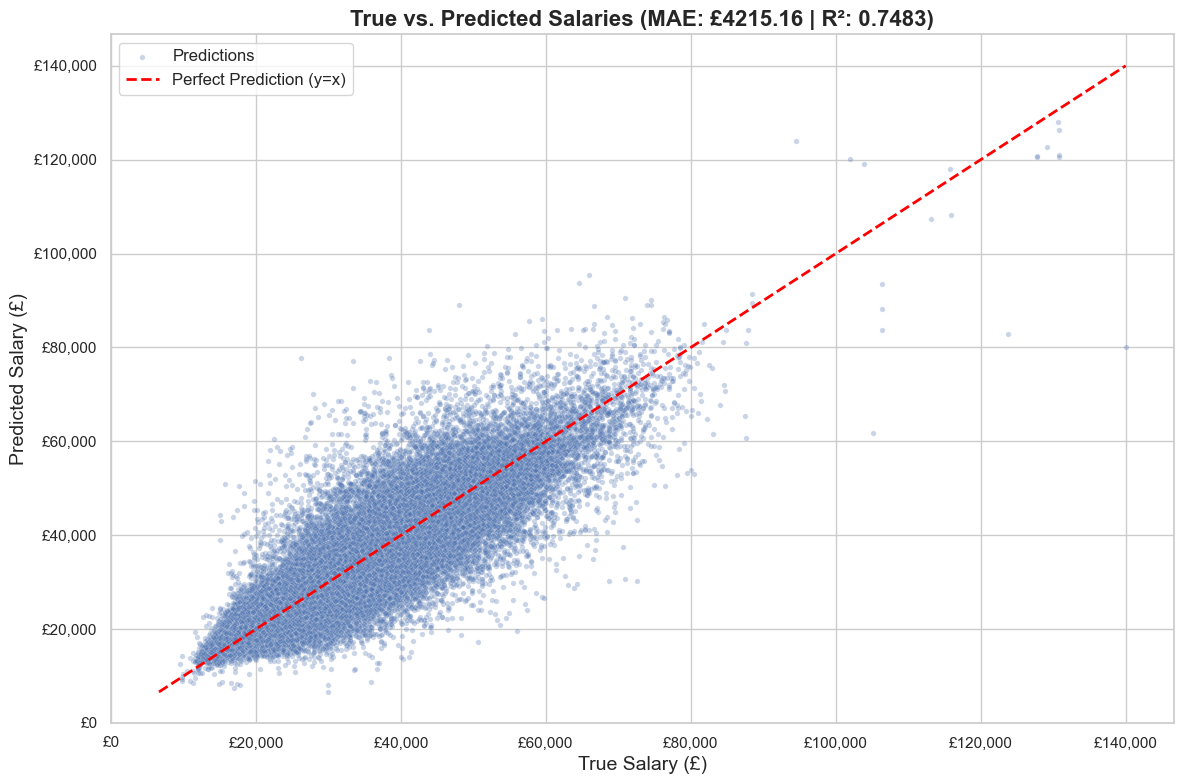

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Painting the Exodia Masterpiece...")

# Set the style to look professional (no boomer default charts here)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. The Scatter Plot
# alpha=0.3 makes the dots see-through so you can see where the data is dense
sns.scatterplot(
    x=y_test, 
    y=final_preds_real, 
    alpha=0.3, 
    color="#4C72B0", 
    s=15, # dot size
    label="Predictions"
)

# 2. The Line of Perfect Prediction (y = x)
# If a dot lands on this red dashed line, your model guessed the exact right penny.
min_val = min(y_test.min(), final_preds_real.min())
max_val = max(y_test.max(), final_preds_real.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label="Perfect Prediction (y=x)"
)

# 3. Flex the labels and title
plt.title(f"True vs. Predicted Salaries (MAE: £{final_mae:.2f} | R²: {final_r2:.4f})", fontsize=16, fontweight='bold')
plt.xlabel("True Salary (£)", fontsize=14)
plt.ylabel("Predicted Salary (£)", fontsize=14)

# Format the axes to show "£" (because we are fancy like that)
import matplotlib.ticker as ticker
formatter = ticker.StrMethodFormatter('£{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(fontsize=12)
plt.tight_layout()

# Render the absolute cinema
plt.show()